In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# eda_table 불러오기

# notebooks/03_symptom_patterns.ipynb 기준으로 상위 디렉터리가 프로젝트 루트라고 가정
BASE_DIR = Path("..").resolve()
EDA_TABLE_PATH = BASE_DIR / "data" / "processed" / "eda_table.csv"

print("EDA_TABLE_PATH:", EDA_TABLE_PATH)

df = pd.read_csv(EDA_TABLE_PATH)
df.head()


EDA_TABLE_PATH: C:\Users\heeky\OneDrive\바탕 화면\sva\scalp-vision-agent\data\processed\eda_table.csv


,sample_id,split,location,gender,age,shampoo_frequency,perm_frequency,dye_frequency,value_1,value_2,value_3,value_4,value_5,value_6
0,0013_A2LEBJJDE00060O_1606550825417_3_TH,train,TH,F,40,1일 1회,1~3회/연,1~3회/연,0,0,0,0,0,0
1,0177_A2LEBJJDE00152B_1604650530904_6_BH,train,BH,F,70,1일 1회,하지않음,하지않음,0,0,0,0,0,0
2,0335_A2LEBJJDE00013X_1602916465540_6_BH,train,BH,F,40,1일 1회,1~3회/연,4~6회/연,0,0,0,0,0,0
3,0335_A2LEBJJDE000542_1605676381132_4_LH,train,LH,M,30,1일 1회,하지않음,하지않음,0,0,0,0,0,0
4,0425_A2LEBJJDE00079P_1605793927978_5_RH,train,RH,F,70,1일 1회,7회 이상/연,하지않음,0,0,0,0,0,0


In [3]:
# value_1~6 기본 분포 확인

symptom_cols = [f"value_{i}" for i in range(1, 7)]
print("증상 컬럼:", symptom_cols)

df[symptom_cols].describe()

for col in symptom_cols:
    print(f"\n=== {col} 분포 ===")
    print(df[col].value_counts().sort_index())


증상 컬럼: ['value_1', 'value_2', 'value_3', 'value_4', 'value_5', 'value_6']

=== value_1 분포 ===
value_1
0    75452
1     5702
2     7062
3     2940
Name: count, dtype: int64

=== value_2 분포 ===
value_2
0    18136
1    36193
2    31945
3     4882
Name: count, dtype: int64

=== value_3 분포 ===
value_3
0    29561
1    39217
2    16859
3     5519
Name: count, dtype: int64

=== value_4 분포 ===
value_4
0    86907
1     2841
2      981
3      427
Name: count, dtype: int64

=== value_5 분포 ===
value_5
0    54551
1    21415
2    12287
3     2903
Name: count, dtype: int64

=== value_6 분포 ===
value_6
0    67570
1    17549
2     4959
3     1078
Name: count, dtype: int64


In [4]:
# matplotlib 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

In [5]:
# 두 증상 쌍에 대한 교차표 + 행 기준 비율 + 시각화 함수

def show_symptom_crosstab(
    df: pd.DataFrame,
    col_a: str,
    col_b: str,
    normalize: bool = True,
) -> None:
    """
    col_a, col_b: 'value_1' ~ 'value_6' 중 하나
    normalize=True일 때 행 기준 비율(조건부 분포)을 함께 보여준다.
    """
    ct = pd.crosstab(df[col_a], df[col_b])  # 4x4 교차표
    print(f"=== {col_a} vs {col_b} 교차표 (빈도) ===")
    display(ct)

    if normalize:
        row_norm = ct.div(ct.sum(axis=1), axis=0)
        print(f"\n=== {col_a}별 {col_b} 등급 분포 (행 기준 비율) ===")
        display((row_norm * 100).round(1))  # % 단위

        # 간단 heatmap 시각화
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(row_norm.values, aspect="auto")

        ax.set_xticks(range(row_norm.shape[1]))
        ax.set_xticklabels(row_norm.columns)
        ax.set_yticks(range(row_norm.shape[0]))
        ax.set_yticklabels(row_norm.index)

        ax.set_xlabel(col_b)
        ax.set_ylabel(col_a)
        ax.set_title(f"{col_a} vs {col_b} (행 기준 비율)")

        # 각 셀에 숫자 표시
        for i in range(row_norm.shape[0]):
            for j in range(row_norm.shape[1]):
                value = row_norm.values[i, j] * 100
                ax.text(
                    j,
                    i,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if value > 25 else "black",
                )

        fig.colorbar(im, ax=ax, label="비율")
        plt.tight_layout()
        plt.show()


=== value_4 vs value_6 교차표 (빈도) ===


value_6,0,1,2,3
value_4,,,,
0,65054,16390,4516,947
1,1606,854,299,82
2,587,233,121,40
3,323,72,23,9



=== value_4별 value_6 등급 분포 (행 기준 비율) ===


value_6,0,1,2,3
value_4,,,,
0,74.9,18.9,5.2,1.1
1,56.5,30.1,10.5,2.9
2,59.8,23.8,12.3,4.1
3,75.6,16.9,5.4,2.1


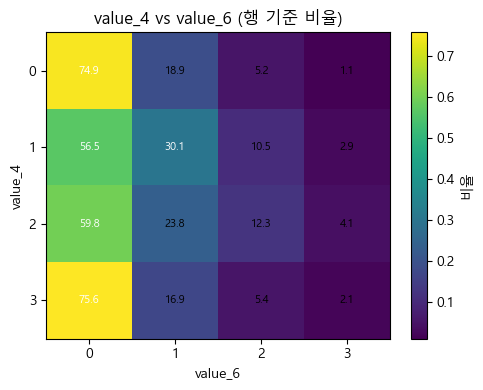

In [17]:
show_symptom_crosstab(df, "value_4", "value_6")

# 다른 조합도 보고 싶으면 아래처럼 바꿔가며 실행:
# show_symptom_crosstab(df, "value_3", "value_6")  # 모낭 사이 홍반 vs 탈모
# show_symptom_crosstab(df, "value_4", "value_6")  # 모낭 홍반/농포 vs 탈모


In [7]:
# Cramér's V 계산 함수 + value_1~6 상관 매트릭스

def cramers_v_from_crosstab(ct: pd.DataFrame) -> float:
    """
    교차표(ct)에서 Cramér's V 계산.
    """
    values = ct.values.astype(float)
    n = values.sum()
    if n == 0:
        return np.nan

    row_sums = values.sum(axis=1, keepdims=True)
    col_sums = values.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n

    # expected가 0인 곳은 chi-square에 기여하지 않도록 처리
    mask = expected > 0
    chi2 = ((values[mask] - expected[mask]) ** 2 / expected[mask]).sum()

    r, c = values.shape
    k = min(r, c)
    if k <= 1:
        return np.nan

    return float(np.sqrt(chi2 / (n * (k - 1))))


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    ct = pd.crosstab(x, y)
    return cramers_v_from_crosstab(ct)


symptom_cols = [f"value_{i}" for i in range(1, 7)]
V = pd.DataFrame(index=symptom_cols, columns=symptom_cols, dtype=float)

for i in symptom_cols:
    for j in symptom_cols:
        V.loc[i, j] = cramers_v(df[i], df[j])

print("=== Cramér's V matrix (value_1 ~ value_6) ===")
display(V)


=== Cramér's V matrix (value_1 ~ value_6) ===


,value_1,value_2,value_3,value_4,value_5,value_6
value_1,1.000000,0.447689,0.028808,0.011389,0.074001,0.024114
value_2,0.447689,1.000000,0.040617,0.014750,0.077650,0.033762
value_3,0.028808,0.040617,1.000000,0.072442,0.036614,0.066654
value_4,0.011389,0.014750,0.072442,1.000000,0.034932,0.051378
value_5,0.074001,0.077650,0.036614,0.034932,1.000000,0.071035
value_6,0.024114,0.033762,0.066654,0.051378,0.071035,1.000000


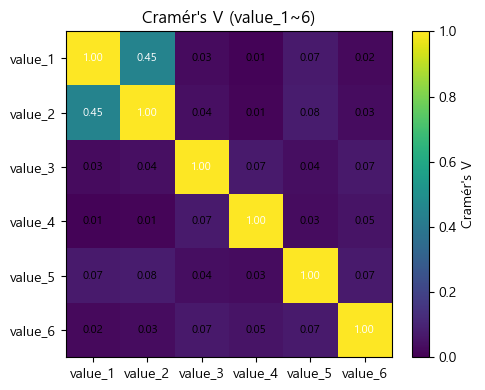

In [8]:
# Cramér's V 히트맵

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(V.values, vmin=0, vmax=1)

ax.set_xticks(range(len(symptom_cols)))
ax.set_xticklabels(symptom_cols)
ax.set_yticks(range(len(symptom_cols)))
ax.set_yticklabels(symptom_cols)

ax.set_title("Cramér's V (value_1~6)")
fig.colorbar(im, ax=ax, label="Cramér's V")

# 셀에 값도 표시
for i in range(len(symptom_cols)):
    for j in range(len(symptom_cols)):
        value = V.values[i, j]
        if np.isnan(value):
            text = "nan"
        else:
            text = f"{value:.2f}"
        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=8,
            color="white" if value > 0.3 else "black",
        )

plt.tight_layout()
plt.show()


In [9]:
# 각 증상에 대해 sev_i = (value_i >= 2) 플래그 만들기

sev_cols: list[str] = []

for i in range(1, 7):
    v_col = f"value_{i}"
    s_col = f"sev_{i}"
    df[s_col] = (df[v_col] >= 2).astype(int)
    sev_cols.append(s_col)

print("심각도 플래그 컬럼:", sev_cols)

df[sev_cols].mean().sort_index()  # 각 sev_i 비율 (심각도 >=2 비율)


심각도 플래그 컬럼: ['sev_1', 'sev_2', 'sev_3', 'sev_4', 'sev_5', 'sev_6']


sev_1    0.109724
sev_2    0.404000
sev_3    0.245491
sev_4    0.015446
sev_5    0.166637
sev_6    0.066227
dtype: float64

In [10]:
# sev_1~sev_6 동시 출현 횟수 & 비율

co_occ_count = pd.DataFrame(
    index=sev_cols,
    columns=sev_cols,
    dtype=int,
)

co_occ_rate = pd.DataFrame(
    index=sev_cols,
    columns=sev_cols,
    dtype=float,
)

for i in sev_cols:
    for j in sev_cols:
        both = ((df[i] == 1) & (df[j] == 1)).sum()
        co_occ_count.loc[i, j] = int(both)
        # i가 1인 샘플 중에서 j도 1인 비율
        base = (df[i] == 1).sum()
        co_occ_rate.loc[i, j] = both / base if base > 0 else np.nan

print("=== sev_i & sev_j 동시 출현 횟수 ===")
display(co_occ_count)

print("\n=== sev_i=1인 샘플 중 sev_j=1 비율 ===")
display((co_occ_rate * 100).round(1))


=== sev_i & sev_j 동시 출현 횟수 ===


,sev_1,sev_2,sev_3,sev_4,sev_5,sev_6
sev_1,10002.0,180.0,2892.0,173.0,1851.0,505.0
sev_2,180.0,36827.0,8539.0,640.0,7728.0,2103.0
sev_3,2892.0,8539.0,22378.0,808.0,4055.0,2212.0
sev_4,173.0,640.0,808.0,1408.0,385.0,193.0
sev_5,1851.0,7728.0,4055.0,385.0,15190.0,407.0
sev_6,505.0,2103.0,2212.0,193.0,407.0,6037.0



=== sev_i=1인 샘플 중 sev_j=1 비율 ===


,sev_1,sev_2,sev_3,sev_4,sev_5,sev_6
sev_1,100.0,1.8,28.9,1.7,18.5,5.0
sev_2,0.5,100.0,23.2,1.7,21.0,5.7
sev_3,12.9,38.2,100.0,3.6,18.1,9.9
sev_4,12.3,45.5,57.4,100.0,27.3,13.7
sev_5,12.2,50.9,26.7,2.5,100.0,2.7
sev_6,8.4,34.8,36.6,3.2,6.7,100.0


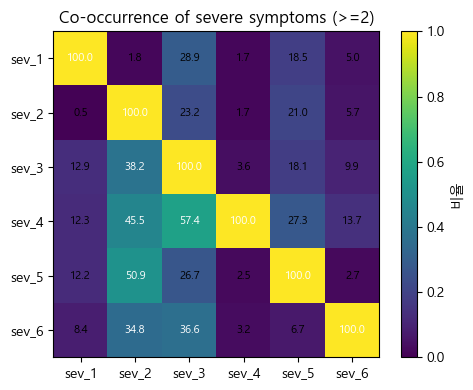

In [11]:
# sev_i 동시 출현 비율 히트맵

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(co_occ_rate.values, vmin=0, vmax=1)

ax.set_xticks(range(len(sev_cols)))
ax.set_xticklabels(sev_cols)
ax.set_yticks(range(len(sev_cols)))
ax.set_yticklabels(sev_cols)

ax.set_title("Co-occurrence of severe symptoms (>=2)")
fig.colorbar(im, ax=ax, label="비율")

for i in range(len(sev_cols)):
    for j in range(len(sev_cols)):
        value = co_occ_rate.values[i, j]
        if np.isnan(value):
            text = "nan"
        else:
            text = f"{value*100:.1f}"
        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=8,
            color="white" if (not np.isnan(value) and value > 0.3) else "black",
        )

plt.tight_layout()
plt.show()
